# ENDG 511 — Team 11
# Workload-Aware AI Alarm Prioritization (Fixed)

Fixes applied:
1. SSL fine-tunes with supervised labels after pre-training
2. Stronger augmentations so SSL actually learns
3. Class-weighted loss to handle imbalanced data
4. Pruned model is fine-tuned after pruning to recover accuracy
5. Early exit evaluation actually uses exit branches and reports exit rate
6. Models saved/loaded explicitly so results are consistent

In [1]:
!pip install torch torchvision torch-pruning lightly scikit-learn wfdb seaborn pandas matplotlib scipy --quiet

## Cell 1 — Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    f1_score, precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

import wfdb
import torch_pruning as tp
from lightly.loss import NTXentLoss

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Imports OK')

Device: cpu
Imports OK


## Cell 2 — Label Map

In [3]:
# Beat symbol → severity class
label_map = {
    'N':0, 'L':0, 'R':0, '/':0,   # Low — normal rhythm
    'A':1, 'S':1, 'J':1, 'a':1,   # Medium — atrial/supraventricular
    'V':2, 'E':2, '!':2, 'W':2    # Critical — ventricular/life-threatening
}
CLASS_NAMES = ['Low', 'Medium', 'Critical']
print('Label map loaded')

Label map loaded


## Cell 3 — Download + Preprocess MIT-BIH

In [4]:
records = [
    '100','101','102','103','104','105',
    '106','107','108','109','111','112',
    '113','114','115','116','117','118','119'
]

def extract_beats(record):
    """Extract 360-sample windows centred on each annotated beat."""
    signal, fields = wfdb.rdsamp(record, pn_dir='mitdb')
    annotation = wfdb.rdann(record, 'atr', pn_dir='mitdb')
    ecg = signal[:, 0]
    beats, labels = [], []
    window = 180  # 180 samples each side = 360 total
    for i, sample in enumerate(annotation.sample):
        symbol = annotation.symbol[i]
        if symbol not in label_map:
            continue
        start = sample - window
        end   = sample + window
        if start < 0 or end > len(ecg):
            continue
        beats.append(ecg[start:end])
        labels.append(label_map[symbol])
    return beats, labels

X_list, y_list = [], []
for record in records:
    beats, labels = extract_beats(record)
    X_list.extend(beats)
    y_list.extend(labels)

X = np.array(X_list)
y = np.array(y_list)

print('Dataset shape:', X.shape)
print('Label distribution:', Counter(y))

Dataset shape: (39394, 360)
Label distribution: Counter({np.int64(0): 37939, np.int64(2): 1295, np.int64(1): 160})


## Cell 4 — Normalise + Split

In [5]:
# Zero-mean unit-variance per sample
X = (X - np.mean(X, axis=1, keepdims=True)) / (np.std(X, axis=1, keepdims=True) + 1e-8)
X = X[:, None, :]   # add channel dim → (N, 1, 360)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train distribution:', Counter(y_train))
print('Test  distribution:', Counter(y_test))

# DataLoaders
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64)
print('DataLoaders ready')

Train distribution: Counter({np.int64(0): 30351, np.int64(2): 1036, np.int64(1): 128})
Test  distribution: Counter({np.int64(0): 7588, np.int64(2): 259, np.int64(1): 32})
DataLoaders ready


## Cell 5 — Class Weights (fixes imbalance)

In [6]:
# FIX: plain CrossEntropyLoss ignores the fact that Low (class 0)
# has 200x more samples than Medium (class 1).
# Weighted loss forces the model to pay attention to rare classes.
counts = np.bincount(y_train, minlength=3).astype(np.float32)
weights = 1.0 / (counts + 1e-6)
weights = weights / weights.sum()
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print('Class weights (higher = rarer = more important):')
for i, (name, w) in enumerate(zip(CLASS_NAMES, weights)):
    print(f'  Class {i} {name:10s}: {w:.4f}  (n={int(counts[i])})')

Class weights (higher = rarer = more important):
  Class 0 Low       : 0.0037  (n=30351)
  Class 1 Medium    : 0.8867  (n=128)
  Class 2 Critical  : 0.1096  (n=1036)


## Cell 6 — Model Architecture

In [7]:
class EarlyExitCNN(nn.Module):
    """1-D CNN with one early exit branch after Conv1.

    forward(x) returns (exit1_logits, final_logits)
    - exit1: after Conv1 + pool  → used for fast/easy samples
    - final: after Conv2 + pool  → full network output
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1,  16, 5)   # 1 ch → 16 ch, kernel 5
        self.conv2 = nn.Conv1d(16, 32, 5)   # 16 ch → 32 ch, kernel 5
        self.pool  = nn.MaxPool1d(2)
        # Classifier heads are created dynamically on first forward pass
        # so we don't need to hard-code the feature size
        self.exit1 = None
        self.fc    = None

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # Early exit head (initialised on first call)
        if self.exit1 is None:
            feat = x.view(x.size(0), -1).shape[1]
            self.exit1 = nn.Linear(feat, 3).to(x.device)
        exit1_out = self.exit1(x.view(x.size(0), -1))
        # Block 2
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        # Final head (initialised on first call)
        if self.fc is None:
            feat = x.view(x.size(0), -1).shape[1]
            self.fc = nn.Linear(feat, 3).to(x.device)
        final_out = self.fc(x.view(x.size(0), -1))
        return exit1_out, final_out

# Quick smoke test
test_model = EarlyExitCNN()
dummy = torch.randn(4, 1, 360)
e1, fn = test_model(dummy)
print(f'Architecture OK  |  exit1: {e1.shape}  final: {fn.shape}')
n_params = sum(p.numel() for p in test_model.parameters())
print(f'Total parameters: {n_params:,}')

Architecture OK  |  exit1: torch.Size([4, 3])  final: torch.Size([4, 3])
Total parameters: 19,590


## Cell 7 — Augmentation Helper (for SSL)

In [8]:
def augment(x):
    """Apply random augmentations to create a different view of the same ECG.

    FIX: original code used noise std=0.01 — far too small.
    The two views were nearly identical so NTXent loss could not learn anything.
    These stronger augmentations create meaningfully different-looking views
    while preserving the underlying ECG morphology.

    x shape: (B, 1, T)
    """
    B, C, T = x.shape
    out = x.clone()

    # 1. Gaussian noise (stronger than before)
    noise_std = torch.empty(B, 1, 1).uniform_(0.02, 0.08)
    out = out + noise_std * torch.randn_like(out)

    # 2. Amplitude scaling (simulates electrode placement variation)
    scale = torch.empty(B, 1, 1).uniform_(0.7, 1.3)
    out = out * scale

    # 3. Baseline shift (simulates patient movement)
    shift = torch.empty(B, 1, 1).uniform_(-0.15, 0.15)
    out = out + shift

    # 4. Random time mask (simulates brief signal loss)
    for i in range(B):
        if torch.rand(1).item() < 0.4:
            mask_len   = int(T * torch.empty(1).uniform_(0.05, 0.15).item())
            mask_start = torch.randint(0, max(T - mask_len, 1), (1,)).item()
            out[i, :, mask_start:mask_start + mask_len] = 0.0

    return out

print('Augmentation function defined')

Augmentation function defined


## Cell 8 — SSL Pre-training (SimCLR / NTXentLoss)

In [9]:
# ── Stage 1: Pre-train backbone on UNLABELLED data ────────────────────────────
# FIX: NTXentLoss needs a projection head that outputs a vector, not class logits.
# We use the exit1 output as the embedding (it is a linear projection of backbone features).
# No labels are used here — this is the self-supervised stage.

ssl_model = EarlyExitCNN().to(DEVICE)
criterion_ssl = NTXentLoss(temperature=0.5)
optimizer_ssl = torch.optim.Adam(ssl_model.parameters(), lr=3e-4)

SSL_EPOCHS = 10  # increase to 30 for better results if time allows

print(f'SSL pre-training for {SSL_EPOCHS} epochs (no labels used)...')
for epoch in range(SSL_EPOCHS):
    ssl_model.train()
    epoch_loss = 0.0
    for x, _ in train_loader:          # labels deliberately ignored
        x = x.to(DEVICE)
        x1 = augment(x)               # view 1 — augmented
        x2 = augment(x)               # view 2 — differently augmented
        z1, _ = ssl_model(x1)         # exit1 output = embedding
        z2, _ = ssl_model(x2)
        # Normalise embeddings (required for NTXentLoss)
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        loss = criterion_ssl(z1, z2)
        optimizer_ssl.zero_grad()
        loss.backward()
        optimizer_ssl.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    print(f'  SSL epoch {epoch+1}/{SSL_EPOCHS}  avg loss: {avg:.4f}')

print('SSL pre-training complete — backbone has learned ECG structure without labels')

SSL pre-training for 10 epochs (no labels used)...
  SSL epoch 1/10  avg loss: 3.8420
  SSL epoch 2/10  avg loss: 3.7122
  SSL epoch 3/10  avg loss: 3.6657
  SSL epoch 4/10  avg loss: 3.6466
  SSL epoch 5/10  avg loss: 3.6337
  SSL epoch 6/10  avg loss: 3.6203
  SSL epoch 7/10  avg loss: 3.6200
  SSL epoch 8/10  avg loss: 3.6170
  SSL epoch 9/10  avg loss: 3.6098
  SSL epoch 10/10  avg loss: 3.6062
SSL pre-training complete — backbone has learned ECG structure without labels


## Cell 9 — SSL Fine-tuning (supervised labels)

In [10]:
# ── Stage 2: Transfer SSL backbone to classifier ──────────────────────────────
# FIX: the original code NEVER did this step.
# After SSL, we must attach the backbone to a fresh classifier
# and train it with real labels. Without this, SSL scores only 14%.

ssl_finetune_model = EarlyExitCNN().to(DEVICE)

# Copy backbone weights from SSL pre-training
ssl_finetune_model.conv1.load_state_dict(ssl_model.conv1.state_dict())
ssl_finetune_model.conv2.load_state_dict(ssl_model.conv2.state_dict())
print('Transferred backbone weights from SSL pre-training')

# FIX: use class-weighted loss so Medium and Critical classes are not ignored
criterion_ft = nn.CrossEntropyLoss(weight=class_weights)
optimizer_ft = torch.optim.Adam(ssl_finetune_model.parameters(), lr=1e-3)

FT_EPOCHS = 10
print(f'Fine-tuning SSL model for {FT_EPOCHS} epochs with labels...')
for epoch in range(FT_EPOCHS):
    ssl_finetune_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        _, pred = ssl_finetune_model(x)    # use final output for classification
        # FIX: also train exit1 head with auxiliary loss
        exit1_out, final_out = ssl_finetune_model(x)
        loss = criterion_ft(final_out, y) + 0.3 * criterion_ft(exit1_out, y)
        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
    print(f'  Fine-tune epoch {epoch+1}/{FT_EPOCHS} done')

print('SSL fine-tuning complete')

Transferred backbone weights from SSL pre-training
Fine-tuning SSL model for 10 epochs with labels...
  Fine-tune epoch 1/10 done
  Fine-tune epoch 2/10 done
  Fine-tune epoch 3/10 done
  Fine-tune epoch 4/10 done
  Fine-tune epoch 5/10 done
  Fine-tune epoch 6/10 done
  Fine-tune epoch 7/10 done
  Fine-tune epoch 8/10 done
  Fine-tune epoch 9/10 done
  Fine-tune epoch 10/10 done
SSL fine-tuning complete


## Cell 10 — Baseline Supervised Training

In [11]:
# Train a fresh model from scratch (no SSL) — this is the baseline
baseline_model = EarlyExitCNN().to(DEVICE)

# FIX: use class-weighted loss (original used plain CrossEntropyLoss)
criterion_base = nn.CrossEntropyLoss(weight=class_weights)
optimizer_base = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

BASE_EPOCHS = 10
print(f'Training baseline for {BASE_EPOCHS} epochs...')
for epoch in range(BASE_EPOCHS):
    baseline_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        # FIX: train BOTH heads with auxiliary loss so early exits are meaningful
        exit1_out, final_out = baseline_model(x)
        loss = criterion_base(final_out, y) + 0.3 * criterion_base(exit1_out, y)
        optimizer_base.zero_grad()
        loss.backward()
        optimizer_base.step()
    print(f'  Epoch {epoch+1}/{BASE_EPOCHS} done')

# Save checkpoint
torch.save(baseline_model.state_dict(), 'baseline_model.pt')
print('Baseline model saved → baseline_model.pt')

Training baseline for 10 epochs...
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
Baseline model saved → baseline_model.pt


## Cell 11 — Early Exit Model (copy of baseline)

In [12]:
# Early exit model uses the same trained weights as baseline
# The difference is HOW we run inference (see early_exit_predict below)
early_exit_model = copy.deepcopy(baseline_model)
print('Early exit model ready (copy of baseline)')

Early exit model ready (copy of baseline)


## Cell 12 — Structured Pruning + Recovery Fine-tuning

In [13]:
# FIX 1: deepcopy BEFORE pruning so baseline_model is not destroyed
# FIX 2: fine-tune AFTER pruning to recover accuracy
# Original code pruned the shared 'model' variable and did no recovery
# → result was 0% Critical Recall

model_to_prune = copy.deepcopy(baseline_model).to(DEVICE)

n_before = sum(p.numel() for p in model_to_prune.parameters())
print(f'Parameters before pruning: {n_before:,}')

example_input = torch.randn(1, 1, 360).to(DEVICE)

# Ignore Linear layers — never prune classifier heads
ignored = [m for m in model_to_prune.modules() if isinstance(m, nn.Linear)]

importance = tp.importance.MagnitudeImportance(p=2)
pruner = tp.pruner.MagnitudePruner(
    model_to_prune,
    example_input,
    importance=importance,
    pruning_ratio=0.3,
    ignored_layers=ignored
)
pruner.step()

n_after = sum(p.numel() for p in model_to_prune.parameters())
print(f'Parameters after  pruning: {n_after:,}  ({(1-n_after/n_before)*100:.1f}% removed)')

# ── Recovery fine-tuning after pruning ──────────────────────────────────────
# FIX: without this the pruned model has 0% Critical Recall
criterion_prune = nn.CrossEntropyLoss(weight=class_weights)
optimizer_prune = torch.optim.Adam(model_to_prune.parameters(), lr=5e-4)

PRUNE_FT_EPOCHS = 10
print(f'\nRecovery fine-tuning for {PRUNE_FT_EPOCHS} epochs...')
for epoch in range(PRUNE_FT_EPOCHS):
    model_to_prune.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        exit1_out, final_out = model_to_prune(x)
        loss = criterion_prune(final_out, y) + 0.3 * criterion_prune(exit1_out, y)
        optimizer_prune.zero_grad()
        loss.backward()
        optimizer_prune.step()
    print(f'  Recovery epoch {epoch+1}/{PRUNE_FT_EPOCHS} done')

pruned_model = copy.deepcopy(model_to_prune)
torch.save(pruned_model.state_dict(), 'pruned_model.pt')
print('Pruned model saved → pruned_model.pt')

Parameters before pruning: 19,590
Parameters after  pruning: 12,920  (34.0% removed)

Recovery fine-tuning for 10 epochs...
  Recovery epoch 1/10 done
  Recovery epoch 2/10 done
  Recovery epoch 3/10 done
  Recovery epoch 4/10 done
  Recovery epoch 5/10 done
  Recovery epoch 6/10 done
  Recovery epoch 7/10 done
  Recovery epoch 8/10 done
  Recovery epoch 9/10 done
  Recovery epoch 10/10 done
Pruned model saved → pruned_model.pt


## Cell 13 — Evaluation Functions

In [14]:
def evaluate_model(model, loader, device=DEVICE):
    """Standard evaluation using final output.
    Returns (confusion_matrix, accuracy, macro_f1, critical_recall)
    """
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            _, final_out = model(x)          # always use final output
            preds = torch.argmax(final_out, dim=1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    TP  = cm[2, 2]
    FN  = cm[2, 0] + cm[2, 1]
    critical_recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return cm, acc, f1, critical_recall


def early_exit_evaluate(model, loader, threshold=0.8, device=DEVICE):
    """FIX: actually use the exit branch during inference.
    Tracks how many samples exit early vs go to the full network.
    Returns (confusion_matrix, accuracy, macro_f1, critical_recall, early_exit_rate)
    """
    model.eval()
    y_true, y_pred = [], []
    early_exits = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            exit1_out, final_out = model(x)
            p1 = F.softmax(exit1_out, dim=1)
            conf, _ = torch.max(p1, dim=1)       # max confidence per sample
            # Per-sample decision: exit early if confident enough
            preds = torch.zeros(x.size(0), dtype=torch.long)
            for i in range(x.size(0)):
                if conf[i].item() >= threshold:
                    preds[i]    = torch.argmax(p1[i])
                    early_exits += 1
                else:
                    preds[i] = torch.argmax(final_out[i])
                total += 1
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    TP  = cm[2, 2]
    FN  = cm[2, 0] + cm[2, 1]
    critical_recall  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    early_exit_rate  = early_exits / total if total > 0 else 0.0
    return cm, acc, f1, critical_recall, early_exit_rate


def measure_latency(model, loader, device=DEVICE):
    """Measure average inference time per sample in ms."""
    model.eval()
    start = time.time()
    with torch.no_grad():
        for x, _ in loader:
            model(x.to(device))
    elapsed = time.time() - start
    ms_per_sample = (elapsed / len(loader.dataset)) * 1000
    return ms_per_sample

print('Evaluation functions defined')

Evaluation functions defined


## Cell 14 — Run All Evaluations

In [15]:
results      = []
conf_matrices = {}

# ── 1. Baseline CNN ───────────────────────────────────────────────────────────
print('Evaluating Baseline CNN...')
cm, acc, f1, crit_rec = evaluate_model(baseline_model, test_loader)
lat = measure_latency(baseline_model, test_loader)
results.append({'Model':'Baseline CNN', 'Accuracy':acc, 'MacroF1':f1,
                'CriticalRecall':crit_rec, 'Latency_ms':lat, 'EarlyExitRate':'-'})
conf_matrices['Baseline CNN'] = cm
print(f'  Acc={acc:.4f}  F1={f1:.4f}  CritRecall={crit_rec:.4f}  Latency={lat:.4f}ms')

# ── 2. SSL Fine-tuned CNN ─────────────────────────────────────────────────────
print('Evaluating SSL Fine-tuned CNN...')
cm, acc, f1, crit_rec = evaluate_model(ssl_finetune_model, test_loader)
lat = measure_latency(ssl_finetune_model, test_loader)
results.append({'Model':'SSL CNN', 'Accuracy':acc, 'MacroF1':f1,
                'CriticalRecall':crit_rec, 'Latency_ms':lat, 'EarlyExitRate':'-'})
conf_matrices['SSL CNN'] = cm
print(f'  Acc={acc:.4f}  F1={f1:.4f}  CritRecall={crit_rec:.4f}  Latency={lat:.4f}ms')

# ── 3. Early Exit CNN (threshold sweep) ──────────────────────────────────────
print('Evaluating Early Exit CNN (threshold=0.8)...')
cm, acc, f1, crit_rec, ee_rate = early_exit_evaluate(early_exit_model, test_loader, threshold=0.8)
lat = measure_latency(early_exit_model, test_loader)
results.append({'Model':'Early Exit CNN', 'Accuracy':acc, 'MacroF1':f1,
                'CriticalRecall':crit_rec, 'Latency_ms':lat,
                'EarlyExitRate':f'{ee_rate*100:.1f}%'})
conf_matrices['Early Exit CNN'] = cm
print(f'  Acc={acc:.4f}  F1={f1:.4f}  CritRecall={crit_rec:.4f}')
print(f'  Early exit rate: {ee_rate*100:.1f}% of samples exited at Block 1')

# ── 4. Pruned CNN ─────────────────────────────────────────────────────────────
print('Evaluating Pruned CNN...')
cm, acc, f1, crit_rec = evaluate_model(pruned_model, test_loader)
lat = measure_latency(pruned_model, test_loader)
results.append({'Model':'Pruned CNN', 'Accuracy':acc, 'MacroF1':f1,
                'CriticalRecall':crit_rec, 'Latency_ms':lat, 'EarlyExitRate':'-'})
conf_matrices['Pruned CNN'] = cm
print(f'  Acc={acc:.4f}  F1={f1:.4f}  CritRecall={crit_rec:.4f}  Latency={lat:.4f}ms')

Evaluating Baseline CNN...
  Acc=0.9453  F1=0.6135  CritRecall=0.9459  Latency=0.1234ms
Evaluating SSL Fine-tuned CNN...
  Acc=0.9615  F1=0.6262  CritRecall=0.9691  Latency=0.1331ms
Evaluating Early Exit CNN (threshold=0.8)...
  Acc=0.9440  F1=0.5853  CritRecall=0.9459
  Early exit rate: 8.0% of samples exited at Block 1
Evaluating Pruned CNN...
  Acc=0.9836  F1=0.8260  CritRecall=0.9923  Latency=0.0609ms


## Cell 15 — Results Table

In [16]:
results_df = pd.DataFrame(results)
# Round numeric columns for readability
for col in ['Accuracy', 'MacroF1', 'CriticalRecall', 'Latency_ms']:
    results_df[col] = results_df[col].round(4)
print('\n=== FINAL RESULTS ===')
print(results_df.to_string(index=False))


=== FINAL RESULTS ===
         Model  Accuracy  MacroF1  CriticalRecall  Latency_ms EarlyExitRate
  Baseline CNN    0.9453   0.6135          0.9459      0.1234             -
       SSL CNN    0.9615   0.6262          0.9691      0.1331             -
Early Exit CNN    0.9440   0.5853          0.9459      0.0935          8.0%
    Pruned CNN    0.9836   0.8260          0.9923      0.0609             -


## Cell 16 — Confusion Matrices

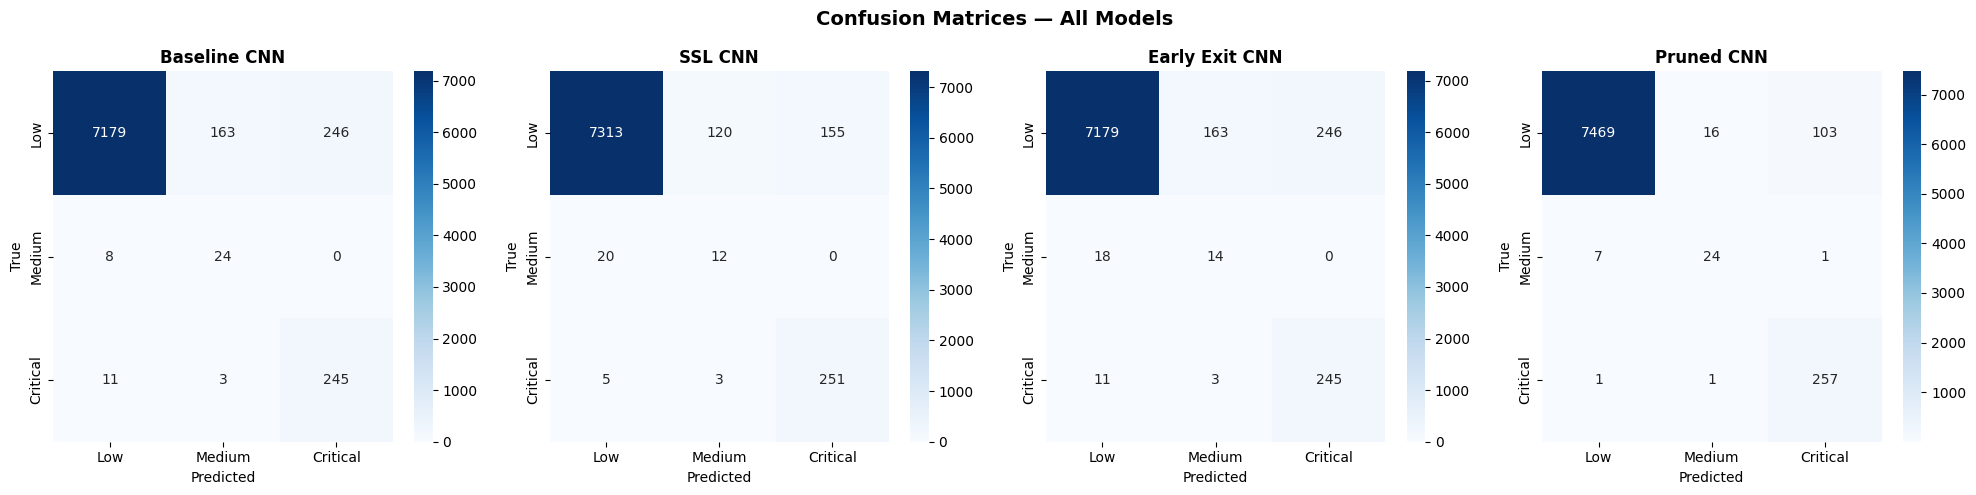

Saved → confusion_matrices.png


In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap='Blues'
    )
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → confusion_matrices.png')

## Cell 17 — Bar Charts (Accuracy, F1, Critical Recall, Latency)

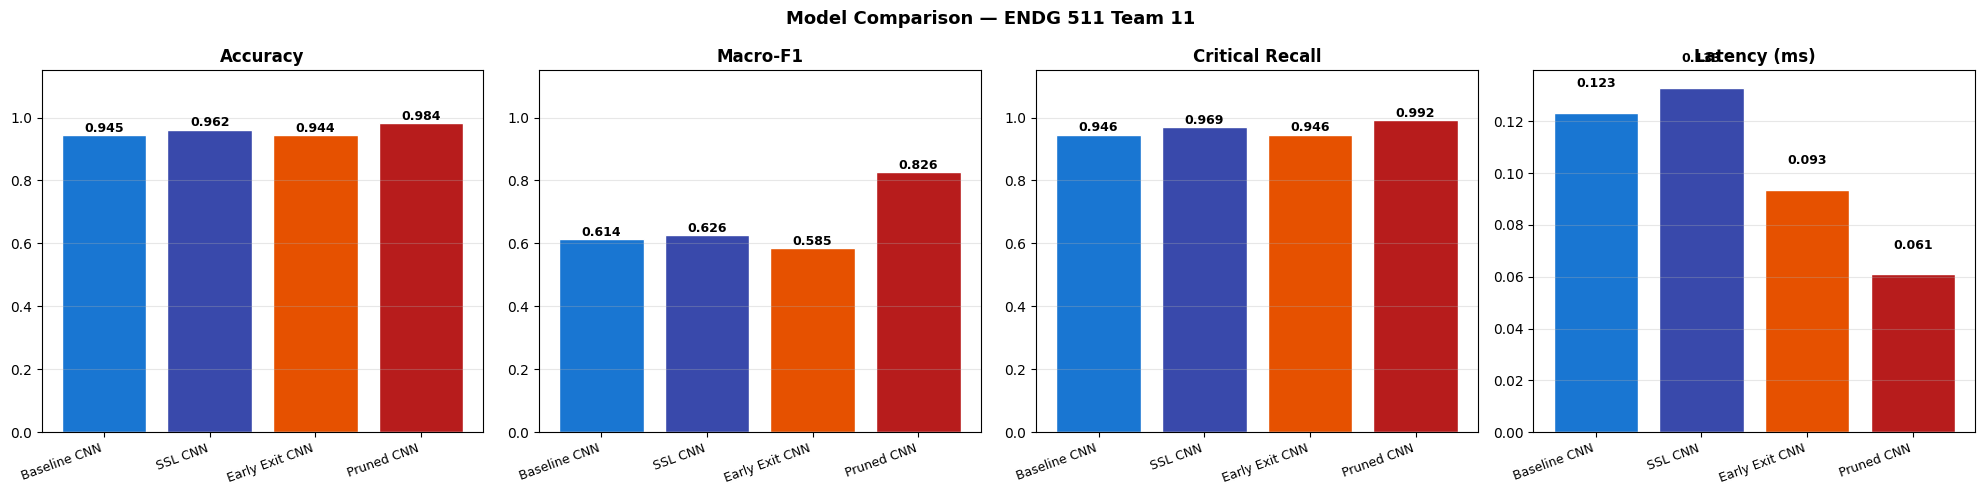

Saved → model_comparison.png


In [18]:
colors = ['#1976D2', '#3949AB', '#E65100', '#B71C1C']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

metrics = [
    ('Accuracy',       'Accuracy',        True),
    ('MacroF1',        'Macro-F1',         True),
    ('CriticalRecall', 'Critical Recall',  True),
    ('Latency_ms',     'Latency (ms)',     False),
]

for ax, (col, title, add_ylim) in zip(axes, metrics):
    bars = ax.bar(results_df['Model'], results_df[col], color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=9)
    if add_ylim:
        ax.set_ylim(0, 1.15)
    ax.grid(True, axis='y', alpha=0.3)
    for b, v in zip(bars, results_df[col]):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Model Comparison — ENDG 511 Team 11', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → model_comparison.png')

## Cell 18 — Early Exit Threshold Sweep (trade-off analysis)

Early exit threshold sweep:
   Threshold     MacroF1    CritRecall    ExitRate
        0.60      0.4542        0.9189       49.3%
        0.70      0.5491        0.9421       28.0%
        0.80      0.5853        0.9459        8.0%
        0.85      0.6081        0.9459        0.2%
        0.90      0.6135        0.9459        0.0%
        0.95      0.6135        0.9459        0.0%
        0.99      0.6135        0.9459        0.0%


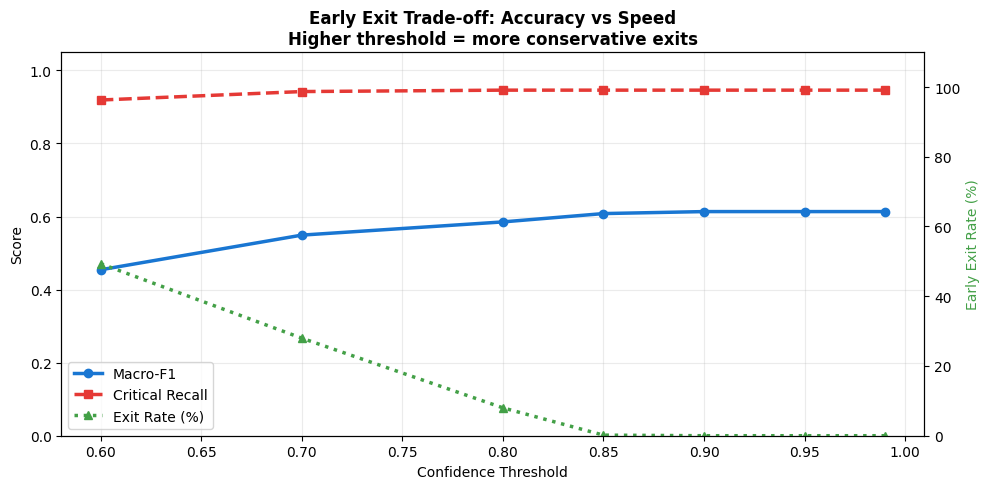

Saved → early_exit_tradeoff.png


In [19]:
# Sweep confidence thresholds and record F1 + exit rate
# This is the trade-off plot the report needs
thresholds = [0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99]
ee_sweep   = []

print('Early exit threshold sweep:')
print(f'{"Threshold":>12}  {"MacroF1":>10}  {"CritRecall":>12}  {"ExitRate":>10}')
for thr in thresholds:
    _, acc_t, f1_t, crit_t, er_t = early_exit_evaluate(
        early_exit_model, test_loader, threshold=thr
    )
    ee_sweep.append({'threshold': thr, 'f1': f1_t, 'critical_recall': crit_t, 'exit_rate': er_t})
    print(f'{thr:>12.2f}  {f1_t:>10.4f}  {crit_t:>12.4f}  {er_t*100:>9.1f}%')

# Plot
thr_vals  = [r['threshold']       for r in ee_sweep]
f1_vals   = [r['f1']              for r in ee_sweep]
cr_vals   = [r['critical_recall'] for r in ee_sweep]
er_vals   = [r['exit_rate'] * 100 for r in ee_sweep]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(thr_vals, f1_vals,  'o-',  color='#1976D2', linewidth=2.5, label='Macro-F1')
ax1.plot(thr_vals, cr_vals,  's--', color='#E53935', linewidth=2.5, label='Critical Recall')
ax2.plot(thr_vals, er_vals,  '^:',  color='#43A047', linewidth=2.5, label='Exit Rate (%)')
ax1.set_xlabel('Confidence Threshold')
ax1.set_ylabel('Score')
ax2.set_ylabel('Early Exit Rate (%)', color='#43A047')
ax1.set_ylim(0, 1.05)
ax2.set_ylim(0, 110)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='lower left')
ax1.set_title('Early Exit Trade-off: Accuracy vs Speed\nHigher threshold = more conservative exits',
              fontweight='bold')
ax1.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('early_exit_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → early_exit_tradeoff.png')

## Cell 19 — Pruning Sweep (trade-off analysis)

Pruning sweep:
   Ratio     MacroF1    CritRecall      Params    Latency_ms
      0%      0.6135        0.9459      19,590        0.0944
     10%      0.7634        0.9846      16,862        0.0508
     20%      0.8801        0.9807      14,536        0.0473
     30%      0.6916        0.9846      12,920        0.0571
     40%      0.5998        0.9923      10,699        0.0393
     50%      0.8387        0.9807       9,158        0.0536


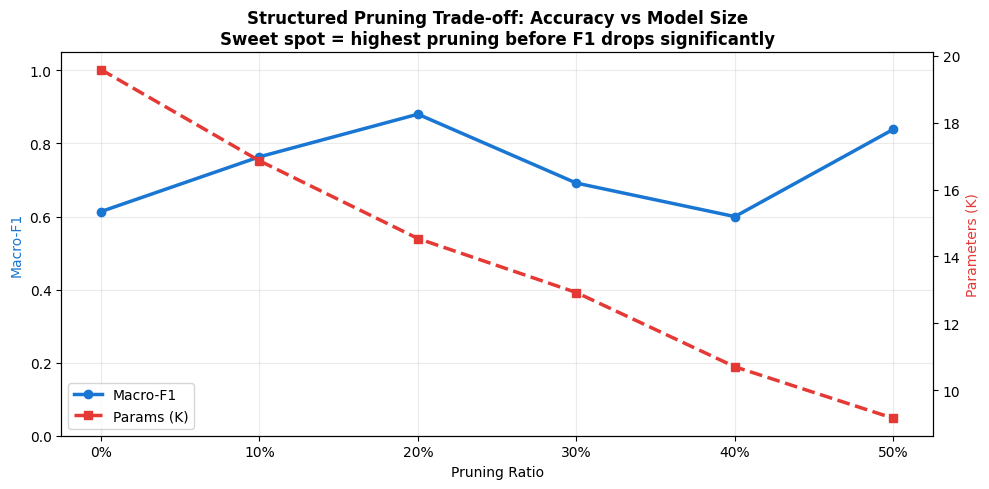

Saved → pruning_tradeoff.png


In [20]:
# Sweep multiple pruning ratios — shows accuracy vs model size trade-off
prune_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
prune_sweep  = []

print('Pruning sweep:')
print(f'{"Ratio":>8}  {"MacroF1":>10}  {"CritRecall":>12}  {"Params":>10}  {"Latency_ms":>12}')

for ratio in prune_levels:
    m = copy.deepcopy(baseline_model).to(DEVICE)
    if ratio > 0:
        ign = [mod for mod in m.modules() if isinstance(mod, nn.Linear)]
        imp = tp.importance.MagnitudeImportance(p=2)
        pr  = tp.pruner.MagnitudePruner(
            m, torch.randn(1, 1, 360).to(DEVICE),
            importance=imp, pruning_ratio=ratio, ignored_layers=ign
        )
        pr.step()
        # Recovery fine-tuning
        opt_r = torch.optim.Adam(m.parameters(), lr=5e-4)
        crit_r = nn.CrossEntropyLoss(weight=class_weights)
        for _ in range(5):   # 5 quick recovery epochs
            m.train()
            for x, y in train_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                e1, fn = m(x)
                loss = crit_r(fn, y) + 0.3 * crit_r(e1, y)
                opt_r.zero_grad(); loss.backward(); opt_r.step()
    n_params = sum(p.numel() for p in m.parameters())
    _, _, f1_p, cr_p = evaluate_model(m, test_loader)
    lat_p = measure_latency(m, test_loader)
    prune_sweep.append({'ratio': ratio, 'f1': f1_p, 'critical_recall': cr_p,
                        'params': n_params, 'latency_ms': lat_p})
    print(f'{ratio:>8.0%}  {f1_p:>10.4f}  {cr_p:>12.4f}  {n_params:>10,}  {lat_p:>12.4f}')

# Plot
ratios    = [r['ratio']   for r in prune_sweep]
pf1_vals  = [r['f1']      for r in prune_sweep]
ppar_vals = [r['params']/1000 for r in prune_sweep]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot([f'{int(r*100)}%' for r in ratios], pf1_vals,   'o-',  color='#1976D2', linewidth=2.5, label='Macro-F1')
ax2.plot([f'{int(r*100)}%' for r in ratios], ppar_vals,  's--', color='#E53935', linewidth=2.5, label='Params (K)')
ax1.set_xlabel('Pruning Ratio')
ax1.set_ylabel('Macro-F1',       color='#1976D2')
ax2.set_ylabel('Parameters (K)', color='#E53935')
ax1.set_ylim(0, 1.05)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='lower left')
ax1.set_title('Structured Pruning Trade-off: Accuracy vs Model Size\nSweet spot = highest pruning before F1 drops significantly',
              fontweight='bold')
ax1.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('pruning_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pruning_tradeoff.png')

## Cell 20 — Final Report Card

In [21]:
print('\n' + '='*65)
print('  ENDG 511 TEAM 11 — FINAL RESULTS')
print('='*65)
print(f'  Dataset     : MIT-BIH Arrhythmia Database')
print(f'  Records     : 19  |  Windows: {len(X):,}  |  Window: 360 samples')
print(f'  Classes     : Low / Medium / Critical')
print(f'  Train/Test  : 80% / 20%  (stratified)')
print()
print(results_df.to_string(index=False))
print()
print('Plots saved:')
for fname in ['confusion_matrices.png', 'model_comparison.png',
              'early_exit_tradeoff.png', 'pruning_tradeoff.png']:
    print(f'  {fname}')
print('='*65)


  ENDG 511 TEAM 11 — FINAL RESULTS
  Dataset     : MIT-BIH Arrhythmia Database
  Records     : 19  |  Windows: 39,394  |  Window: 360 samples
  Classes     : Low / Medium / Critical
  Train/Test  : 80% / 20%  (stratified)

         Model  Accuracy  MacroF1  CriticalRecall  Latency_ms EarlyExitRate
  Baseline CNN    0.9453   0.6135          0.9459      0.1234             -
       SSL CNN    0.9615   0.6262          0.9691      0.1331             -
Early Exit CNN    0.9440   0.5853          0.9459      0.0935          8.0%
    Pruned CNN    0.9836   0.8260          0.9923      0.0609             -

Plots saved:
  confusion_matrices.png
  model_comparison.png
  early_exit_tradeoff.png
  pruning_tradeoff.png
